In [1]:
import os
import copy
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from pytorch_fid import fid_score

In [2]:
#set random seed function
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
#set random seed
set_seed(42)

In [3]:
#choose cpu/gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
#load and transform data
#transform part
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])
#load part
dataset = datasets.CIFAR10(
    root='./data(CIFAR10)', train=True, download=False, transform=transform
)

In [5]:
#loader data
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

In [6]:
#load Train-Loop
%run Train-Loop.ipynb

In [7]:
#load evaluation
%run Evaluation.ipynb

In [8]:
#initialize model
model = UNet().to(device)
ema = EMA(model, decay=0.9995)
#initialize optimizer
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0)

In [9]:
#run train loop
loss_list, sigma_log_list, FID_list, log_snr_collect, loss_collect = train_loop(model, ema, optimizer, max_steps=60000, loader=loader)

Train:  26%|██▌       | 101/391 [00:12<00:33,  8.74it/s]

Step: 100 | Loss Value: 0.2841


Train:  51%|█████▏    | 201/391 [00:23<00:21,  8.68it/s]

Step: 200 | Loss Value: 0.2373


Train:  77%|███████▋  | 301/391 [00:35<00:10,  8.72it/s]

...

Train:  45%|████▌     | 176/391 [00:20<00:24,  8.63it/s]

Step: 60000 | Loss Value: 0.1618



100%|██████████| 782/782 [00:24<00:00, 32.30it/s]

Train:  45%|████▌     | 177/391 [02:59<2:50:06, 47.70s/it]

Step: 60000 -> FID: 14.48586278337649


Train:  45%|████▌     | 177/391 [02:59<03:36,  1.01s/it]  


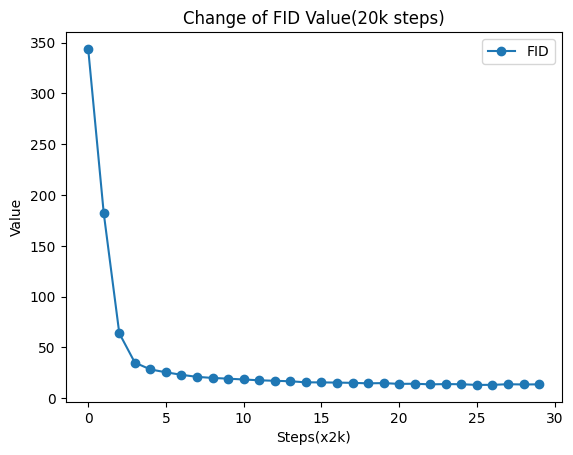

In [10]:
#show the distribution of FID value
plt.figure()
plt.plot(FID_list, marker='o', label='FID')
plt.xlabel('Steps(x2k)')
plt.ylabel('Value')
plt.title('Change of FID Value(20k steps)')
plt.legend(loc='best')
plt.show()

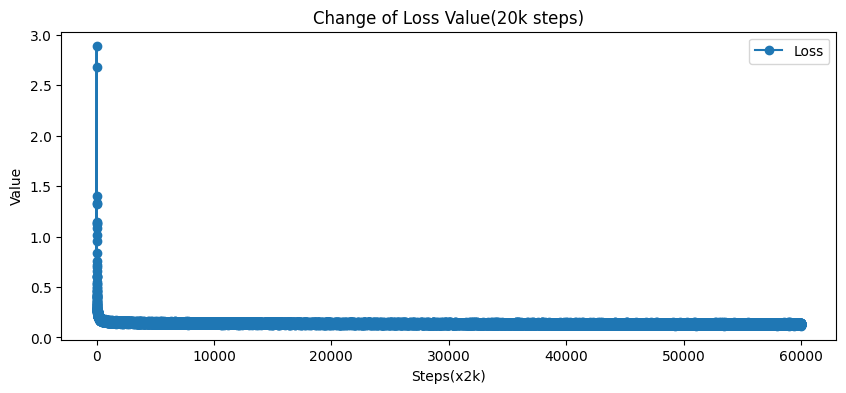

In [11]:
#show the distribution of loss value
plt.figure(figsize=(10, 4))
plt.plot(loss_list, marker='o', label='Loss')
plt.xlabel('Steps(x2k)')
plt.ylabel('Value')
plt.title('Change of Loss Value(20k steps)')
plt.legend(loc='best')
plt.show()

In [12]:
#compute loss & snr function
def compute_loss_vs_snr(log_snr_all, loss_all, num_bins=20):
    #change format of list
    log_snr_all = torch.cat(log_snr_all)
    loss_all = torch.cat(loss_all)
    log_snr_np = log_snr_all.numpy()
    loss_np = loss_all.numpy()
    #seperate into different bins
    bins = np.linspace(log_snr_np.min(), log_snr_np.max(), num_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    avg_loss = []
    #count different loss value
    for i in range(num_bins):
        mask = (log_snr_np >= bins[i]) & (log_snr_np < bins[i+1])
        if mask.sum() > 0:
            avg_loss.append(loss_np[mask].mean())
        else:
            avg_loss.append(0)

    return bin_centers, np.array(avg_loss)

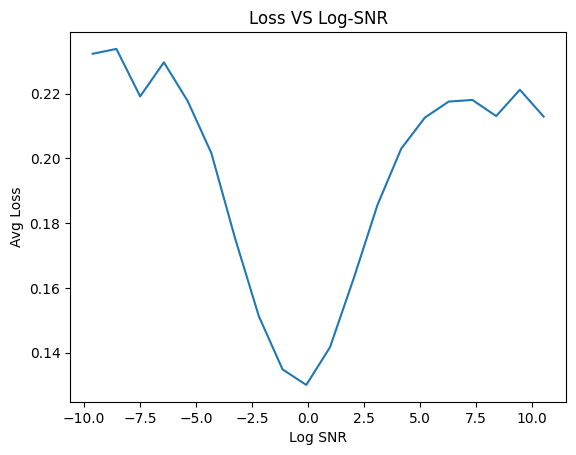

In [13]:
#Loss VS SNR
centers, avg_loss = compute_loss_vs_snr(log_snr_collect, loss_collect)
plt.plot(centers, avg_loss)
plt.title('Loss VS Log-SNR')
plt.xlabel('Log SNR')
plt.ylabel('Avg Loss')
plt.show()